#### Download the dataset from Kaggle, add to current repo

In [1]:
# #local instalations if needed
# %pip install pandas kagglehub scikit-learn matplotlib seaborn

In [2]:
""" import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path) """

' import kagglehub\n\n# Download latest version\npath = kagglehub.competition_download(\'titanic\')\n\nprint("Path to competition files:", path) '

#### Load Data

In [3]:
import pandas as pd

# Load data
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print(train.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

#### Observe dataset and check for Null and duplicated values


In [4]:
# print(train.describe())
print(train.info())
print(f"Columns with missing values:, {train.columns[train.isnull().any()]}")
# Check for duplicates
print(f"Total duplicated rows: {train.duplicated().sum()}")

#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Columns with missing values:, Index(['Age', 'Cabin', 'Embarked'], dtype='object')
Total duplicated rows: 0


#### Handle missing values

In [5]:
# Handle missing values
# Fill 'Embarked' with mode(), most common port of embarkation
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
# Fill 'Age' with median(), the mid range age of passenger
train['Age'] = train['Age'].fillna(train['Age'].median())
"""The `Cabin` values have a first letter followed by a number. 
The letters indicate the deck level, while the numbers indicate the room numbers. 
We create a new column storing the `Deck` information, which contains only the first letter. 
We then drop the `Cabin` column since it contains many missing values, and filling them would not necessarily benefit the accuracy of the model."""
train['Deck']= train['Cabin'].str[0].fillna('Unkown')
print(f"Missing Values:, {train.isnull().sum()}")


Missing Values:, PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck             0
dtype: int64


In [6]:
# Drop irrelevant columns
train = train.drop(columns=['Name','Cabin','Ticket', 'PassengerId'])

In [7]:
survived = train['Survived'].value_counts()
print(survived)


Survived
0    549
1    342
Name: count, dtype: int64


### Feature Engineering 


In [8]:
# Encode categorical variables to numerical for modelling
train = pd.get_dummies(train, dtype=int)
train.info()
train.head(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Sex_female   891 non-null    int64  
 7   Sex_male     891 non-null    int64  
 8   Embarked_C   891 non-null    int64  
 9   Embarked_Q   891 non-null    int64  
 10  Embarked_S   891 non-null    int64  
 11  Deck_A       891 non-null    int64  
 12  Deck_B       891 non-null    int64  
 13  Deck_C       891 non-null    int64  
 14  Deck_D       891 non-null    int64  
 15  Deck_E       891 non-null    int64  
 16  Deck_F       891 non-null    int64  
 17  Deck_G       891 non-null    int64  
 18  Deck_T       891 non-null    int64  
 19  Deck_Unk

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unkown
0,0,3,22.0,1,0,7.2500,0,1,0,0,1,0,0,0,0,0,0,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0,0,0,1,0,0,0,0,0,0


In [9]:
# 1. Define custom fare intervals (or let pandas choose using an integer)
# Bins: 0-20, 20-100, 100-200, 200-600
fare_bins = [0, 20, 100, 200, 600]
fare_labels = ['Budget (<20)', 'Economy (20-100)', 'Business (100-200)', 'Luxury (200+)']

In [10]:
# 2. Create the fare range column
train['Fare_Range'] = pd.cut(train['Fare'], bins=fare_bins, labels=fare_labels, include_lowest=True)

In [11]:
# FamilySize: The total number of family members on the Titanic 
# SibSp = sibilings and spouses abourd the Titanic
# Partch = number of parents and children
# +1 for the original passanger. 
train['FamilySize'] = train['SibSp'] + train['Parch']+1
train['FamilySize']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64

In [12]:
#IsAlone: If the passager is traveling alone 0 is alone 1 is with family 
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
train['IsAlone']

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: IsAlone, Length: 891, dtype: int64

In [13]:
# IsChild: Encoding 1 if passager was under 18, 0 if they were an adult
train['IsChild'] = (train['Age']<18).astype(int) 
train['IsChild'].sum()

113

In [14]:
age_bins = [0, 12, 17, 35, 60, float('inf')]

age_labels = [
    'Child',
    'Teen',
    'YoungAdult',
    'Adult',
    'OlderAdult'
]
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)


#### Explorative Analysis

In [15]:
# Fare of survival rate
print(f"Maximum Fare: ${train['Fare'].max()}")
print(f"Minimum Fare: ${train['Fare'].min()}")

budget = train.loc[train.Fare_Range == 'Budget (<20)','Survived']
budget_survive = budget.mean()
econ = train.loc[train.Fare_Range == 'Economy (20-100)','Survived']
econ_survive = econ.mean()
business = train.loc[train.Fare_Range == 'Business (100-200)','Survived']
business_survive = business.mean()
luxury = train.loc[train.Fare_Range == 'Luxury (200+)','Survived']
luxury_survive = luxury.mean()

print("% of People who got 'Budget' fare that survived:", budget_survive)
print("% of People who got 'Economy' fare that survived:", econ_survive)
print("% of People who got 'Business' fare that survived:", business_survive)
print("% of People who got 'Luxury' fare that survived:", luxury_survive)

Maximum Fare: $512.3292
Minimum Fare: $0.0
% of People who got 'Budget' fare that survived: 0.27766990291262134
% of People who got 'Economy' fare that survived: 0.4953560371517028
% of People who got 'Business' fare that survived: 0.7575757575757576
% of People who got 'Luxury' fare that survived: 0.7


In [16]:
# Survival Rate
print("Survival rate: ", train['Survived'].mean())

Survival rate:  0.3838383838383838


In [17]:
print("Survival by sex, 0 Male, 1 Female:", train.groupby('Sex_female')['Survived'].agg(['count', 'mean']))

Survival by sex, 0 Male, 1 Female:             count      mean
Sex_female                 
0             577  0.188908
1             314  0.742038


In [18]:
print("How likey were children to servive, 0 Adult, 1 child:", train.groupby("IsChild")["Survived"].agg(['count','mean']))

How likey were children to servive, 0 Adult, 1 child:          count      mean
IsChild                 
0          778  0.361183
1          113  0.539823


In [19]:
print("How likey were those traveling alone to servive, 0 none alone, 1 alone:", train.groupby('IsAlone')['Survived'].agg(['count', 'mean']))

How likey were those traveling alone to servive, 0 none alone, 1 alone:          count      mean
IsAlone                 
0          354  0.505650
1          537  0.303538


In [20]:
print(
    "Survivle by sex and class: 0 male, 1 female", train.groupby(['Sex_female', 'Pclass'])['Survived']
    .agg(['count', 'mean'])
)

Survivle by sex and class: 0 male, 1 female                    count      mean
Sex_female Pclass                 
0          1         122  0.368852
           2         108  0.157407
           3         347  0.135447
1          1          94  0.968085
           2          76  0.921053
           3         144  0.500000


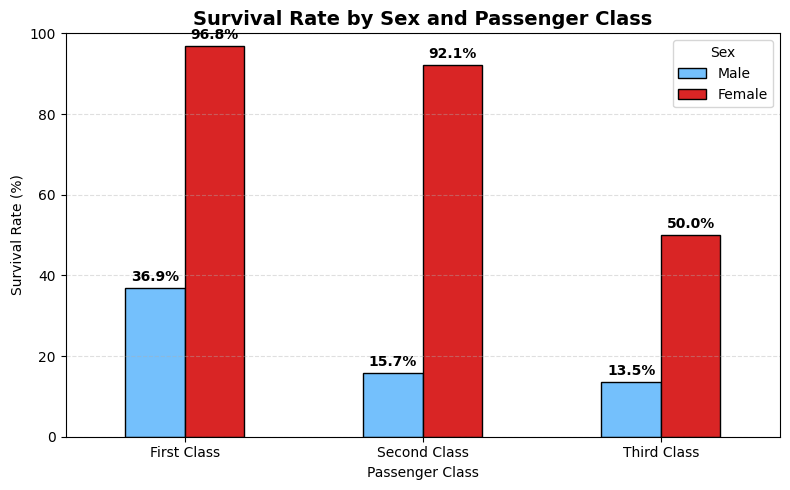

In [21]:
import matplotlib.pyplot as plt
sex_class_survival = (
    train.groupby(['Pclass', 'Sex_female'])['Survived']
    .mean()
    .unstack() * 100
)

sex_class_survival.columns = ['Male', 'Female']

ax = sex_class_survival.plot(
    kind='bar',
    color=['#74C0FC', "#D92525"],
    edgecolor='black',
    figsize=(8, 5)
)

plt.title(
    'Survival Rate by Sex and Passenger Class',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(
    ticks=[0, 1, 2],
    labels=['First Class', 'Second Class', 'Third Class'],
    rotation=0
)
plt.ylim(0, 100)
plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

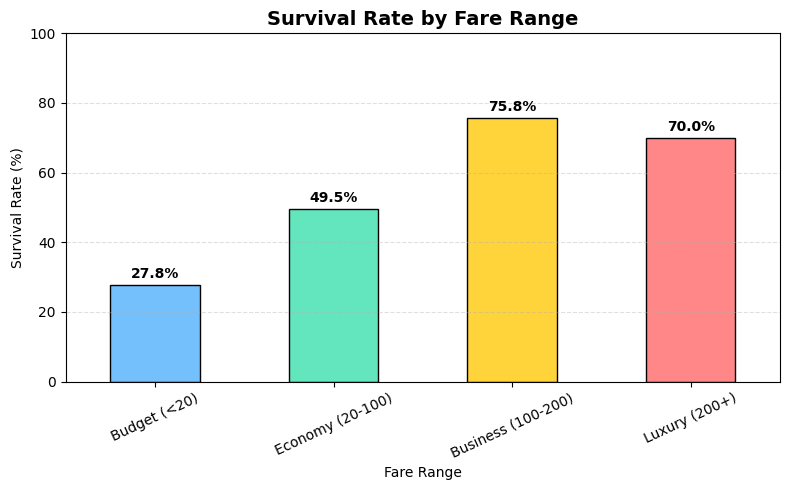

In [22]:
fare_survival = (
    train.groupby('Fare_Range', observed=True)['Survived']
    .mean() * 100
)

colors = ['#74C0FC', '#63E6BE', '#FFD43B', '#FF8787']

ax = fare_survival.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    figsize=(8, 5)
)

plt.title('Survival Rate by Fare Range', fontsize=14, fontweight='bold')
plt.xlabel('Fare Range')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=25)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(fare_survival):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

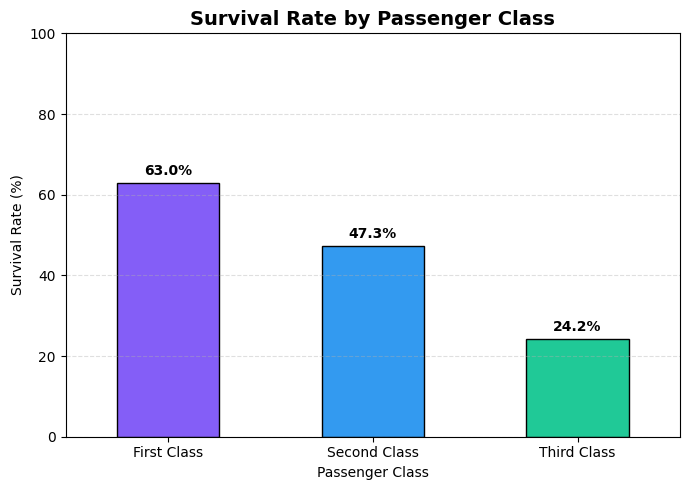

In [23]:
class_survival = (
    train.groupby('Pclass')['Survived']
    .mean() * 100
)

class_survival.index = [
    'First Class',
    'Second Class',
    'Third Class'
]

colors = ['#845EF7', '#339AF0', '#20C997']

ax = class_survival.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    figsize=(7, 5)
)

plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(class_survival):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

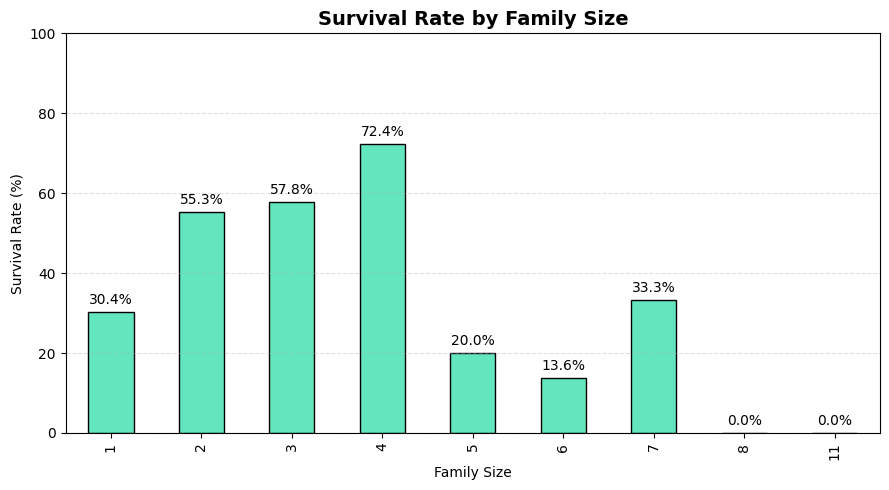

In [24]:
family_survival = (
    train.groupby('FamilySize')['Survived']
    .agg(['count', 'mean'])
)

family_survival['mean'] *= 100

ax = family_survival['mean'].plot(
    kind='bar',
    figsize=(9, 5),
    color='#63E6BE',
    edgecolor='black'
)

plt.title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(family_survival['mean']):
    ax.text(i, value + 2, f'{value:.1f}%', ha='center')

plt.tight_layout()
plt.show()

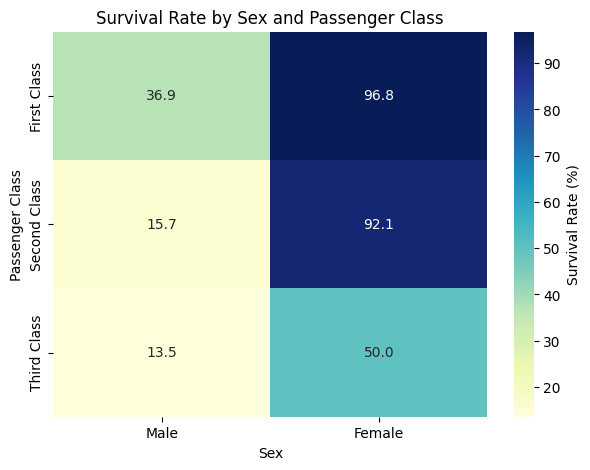

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

survival_heatmap = (
    train.groupby(['Pclass', 'Sex_female'])['Survived']
    .mean()
    .unstack() * 100
)

survival_heatmap.columns = ['Male', 'Female']
survival_heatmap.index = ['First Class', 'Second Class', 'Third Class']

plt.figure(figsize=(7, 5))

sns.heatmap(
    survival_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Survival Rate (%)'}
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Sex')
plt.ylabel('Passenger Class')

plt.show()

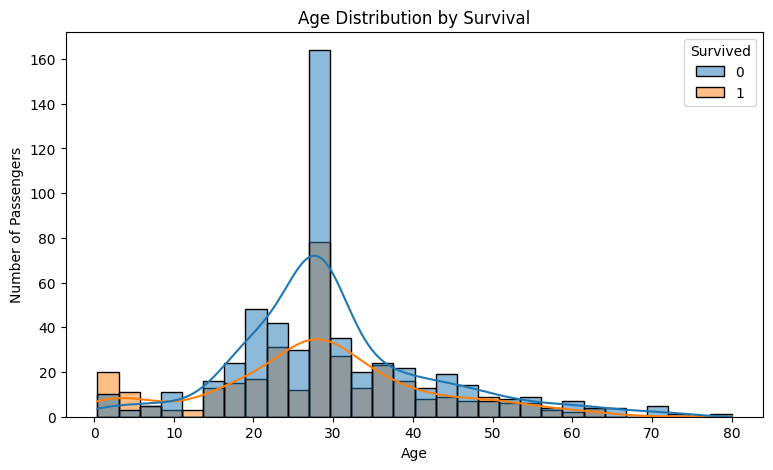

In [26]:


plt.figure(figsize=(9, 5))

sns.histplot(
    data=train,
    x='Age',
    hue='Survived',
    bins=30,
    kde=True,
    alpha=0.5
)

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

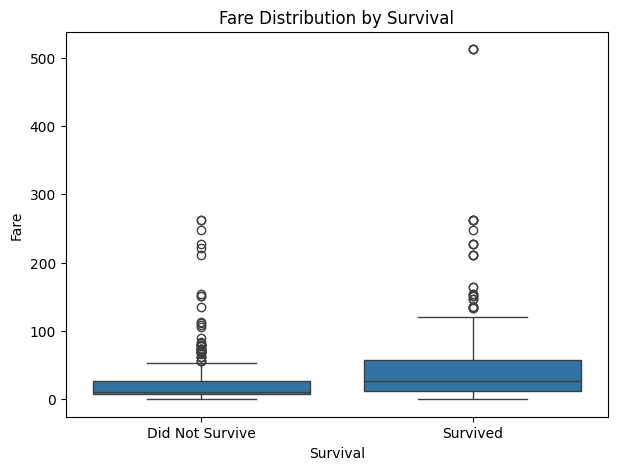

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=train,
    x='Survived',
    y='Fare'
)

plt.title('Fare Distribution by Survival')
plt.xlabel('Survival')
plt.ylabel('Fare')

plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

plt.show()

In [28]:
# One-hot encode fare range column
X_encoded = pd.get_dummies(train, drop_first=True)
X_encoded.dtypes

Survived                           int64
Pclass                             int64
Age                              float64
SibSp                              int64
Parch                              int64
Fare                             float64
Sex_female                         int64
Sex_male                           int64
Embarked_C                         int64
Embarked_Q                         int64
Embarked_S                         int64
Deck_A                             int64
Deck_B                             int64
Deck_C                             int64
Deck_D                             int64
Deck_E                             int64
Deck_F                             int64
Deck_G                             int64
Deck_T                             int64
Deck_Unkown                        int64
FamilySize                         int64
IsAlone                            int64
IsChild                            int64
Fare_Range_Economy (20-100)         bool
Fare_Range_Busin

### Predictive Analysis: Decision Tree and XGBoost


In [29]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    log_loss,
    confusion_matrix,
)
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost is required for this notebook. Install it with `%pip install xgboost`."
    ) from exc

RANDOM_STATE = 42

# Shared feature/target split used by both tree-based models.
X = X_encoded.drop(columns=["Survived"])
y = X_encoded["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Training survival rate: {y_train.mean():.3f}")
print(f"Validation survival rate: {y_val.mean():.3f}")


Training rows: 712
Validation rows: 179
Training survival rate: 0.383
Validation survival rate: 0.385


In [30]:
def evaluate_classifier(model_name, model, X_val, y_val):
    # Evaluate one fitted classifier using the same format for both models.
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "Log Loss": log_loss(y_val, y_prob),
    }

    print(model_name)
    for metric, value in results.items():
        print(f"{metric}: {value:.3f}")
    print("-" * 40)

    cm = confusion_matrix(y_val, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"],
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {results['ROC-AUC']:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("Full Classification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    return results

### Decision Tree

The Decision Tree search tunes tree depth, minimum split size, minimum leaf size, and optional class balancing. The best parameters are selected using mean cross-validated F1-score on the training set.


Best CV F1: 0.757
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree
Accuracy: 0.760
Precision: 0.703
Recall: 0.652
F1 Score: 0.677
ROC-AUC: 0.750
Log Loss: 2.879
----------------------------------------
Confusion Matrix:
[[91 19]
 [24 45]]


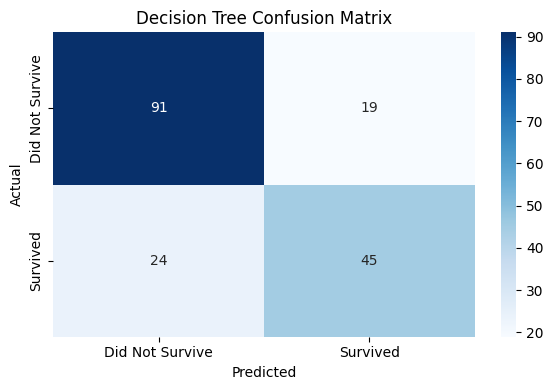

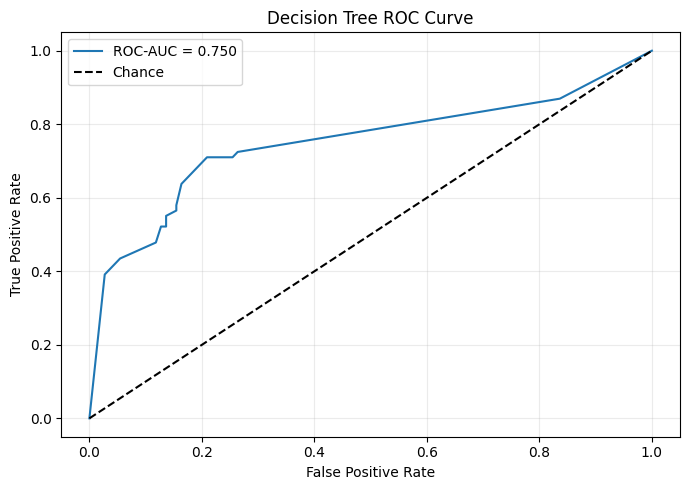

Full Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       110
           1       0.70      0.65      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



In [31]:
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

decision_tree_parameters = {
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

decision_tree_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=decision_tree_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

decision_tree_search.fit(X_train, y_train)
decision_tree_model = decision_tree_search.best_estimator_

print(f"Best CV F1: {decision_tree_search.best_score_:.3f}")
print("Best parameters:", decision_tree_search.best_params_)

decision_tree_results = evaluate_classifier(
    "Decision Tree",
    decision_tree_model,
    X_val,
    y_val,
)

### XGBoost

The XGBoost search tunes the number of trees, tree depth, learning rate, row sampling, and positive-class weighting. The negative-to-positive class ratio is calculated from the training set only.


Training negative-to-positive ratio: 1.608
Best CV F1: 0.777
Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'scale_pos_weight': 1.6080586080586081, 'subsample': 0.8}
XGBoost
Accuracy: 0.788
Precision: 0.718
Recall: 0.739
F1 Score: 0.729
ROC-AUC: 0.828
Log Loss: 0.498
----------------------------------------
Confusion Matrix:
[[90 20]
 [18 51]]


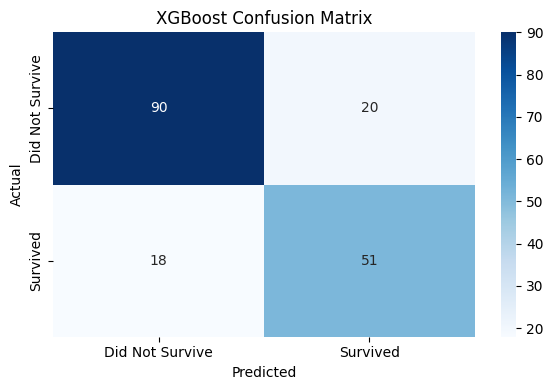

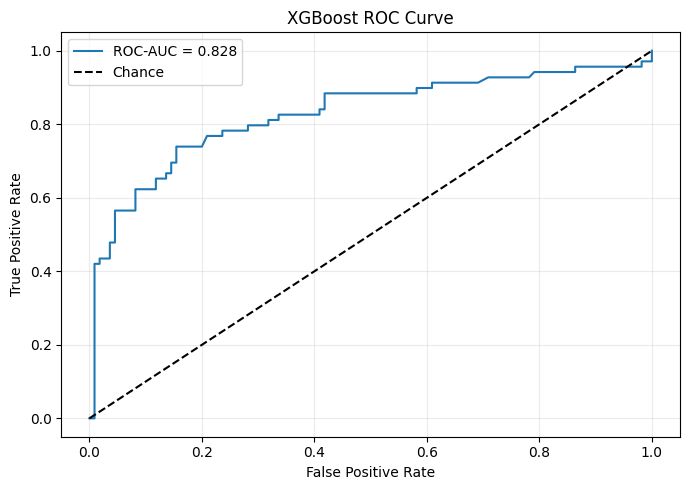

Full Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       110
           1       0.72      0.74      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [32]:
negative_to_positive_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_model = XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

xgboost_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8, 1.0],
    "scale_pos_weight": [1.0, negative_to_positive_ratio],
}

xgboost_search = GridSearchCV(
    estimator=xgboost_model,
    param_grid=xgboost_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

xgboost_search.fit(X_train, y_train)
xgboost_tuned_model = xgboost_search.best_estimator_

print(f"Training negative-to-positive ratio: {negative_to_positive_ratio:.3f}")
print(f"Best CV F1: {xgboost_search.best_score_:.3f}")
print("Best parameters:", xgboost_search.best_params_)

xgboost_results = evaluate_classifier(
    "XGBoost",
    xgboost_tuned_model,
    X_val,
    y_val,
)

### Modeling Notes

- Decision Tree and XGBoost are evaluated separately.
- Hyperparameters are selected with stratified cross-validation on the training set.
- The validation partition is used only to report each fitted model's final metrics and plots.
